/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

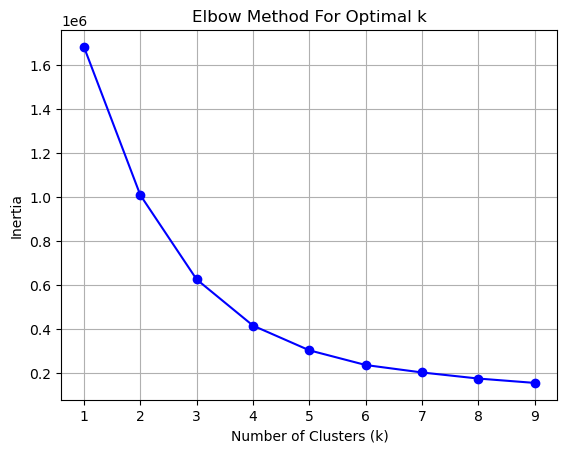

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


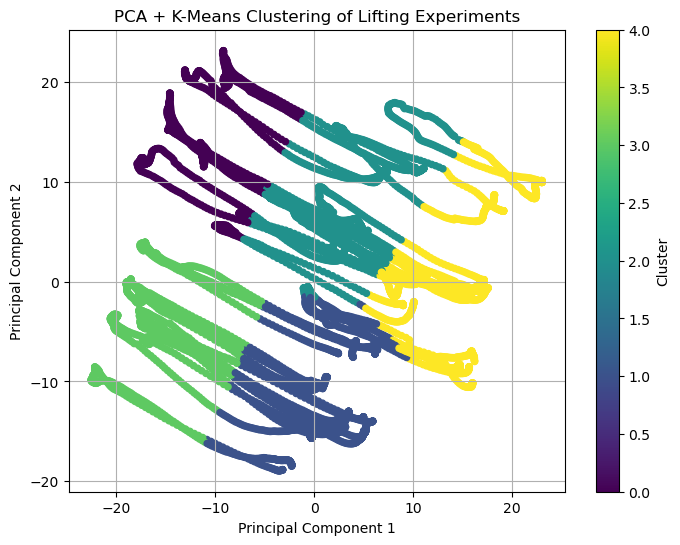

                        size                                   weight
cluster                                                              
0                 [S, L, XL]                   [3, 5, 20, 10, 15, 25]
1         [S, M, L, XL, XXL]  [5, 3, 6, 9, 12, 8, 11, 14, 17, 30, 25]
2        [XS, S, L, XL, XXL]            [1, 3, 5, 20, 10, 15, 25, 30]
3                 [M, L, XL]      [3, 6, 9, 12, 5, 8, 11, 14, 17, 30]
4            [XS, S, L, XXL]            [1, 3, 5, 20, 10, 15, 25, 30]


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Directory where your CSV files are stored
data_folder = 'preprocessed_data/'  # change if needed

# List of (Size, Weight) combinations
experiments = [
    ('XS', 1), ('XS', 3),
    ('S', 1), ('S', 3), ('S', 5),
    ('M', 3), ('M', 6), ('M', 9), ('M', 12),
    ('L', 5), ('L', 8), ('L', 11), ('L', 14), ('L', 17), ('L', 20),
    ('XL', 10), ('XL', 15), ('XL', 20), ('XL', 25), ('XL', 30),
    ('XXL', 10), ('XXL', 15), ('XXL', 20), ('XXL', 25), ('XXL', 30)
]

# Initialize empty lists
all_data = []
all_labels = []

# Read all files
for size, weight in experiments:
    filename = f"{size}_{weight}kg_preprocessed_full.csv"  # change if your files don't have "kg"
    filepath = os.path.join(data_folder, filename)
    
    # Load file with multi-index header
    df = pd.read_csv(filepath, header=[0, 1])

    # Keep only numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_numeric = df[numeric_cols]

    # Fill missing values within this file
    df_numeric = df_numeric.fillna(df_numeric.mean())

    # Save data and labels
    all_data.append(df_numeric)
    all_labels.append(pd.DataFrame({'size': size, 'weight': weight}, index=df_numeric.index))

# Combine all files together
full_data = pd.concat(all_data, axis=0, ignore_index=True)
full_labels = pd.concat(all_labels, axis=0, ignore_index=True)

# --- Handle missing values globally ---
full_data = full_data.fillna(full_data.mean())    # Fill NaNs again globally
full_data = full_data.dropna(axis=1)              # Drop any columns that still have NaNs

# --- Standardize the features ---
scaler = StandardScaler()
full_data_scaled = scaler.fit_transform(full_data)

# --- PCA to 2 components ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(full_data_scaled)

# --- Elbow method to determine the best number of clusters ---
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_result)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

# --- Apply KMeans with chosen k (say 5) ---
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(pca_result)

# Attach cluster labels to the metadata
full_labels['cluster'] = clusters

# --- Visualization ---
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis', s=20)
plt.title('PCA + K-Means Clustering of Lifting Experiments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

# --- Optional: Show what sizes and weights are in each cluster ---
print(full_labels.groupby('cluster')[['size', 'weight']].agg(lambda x: list(x.unique())))

Fitting a model with 211911 free scalar parameters with only 89748 data points will result in a degenerate solution.


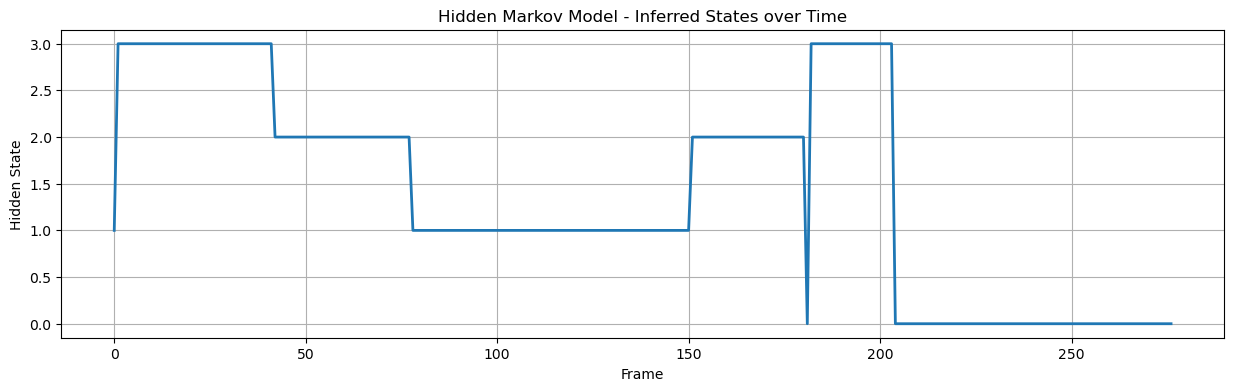

Transition matrix:
[[0.98630137 0.         0.         0.01369863]
 [0.         0.97297297 0.01351351 0.01351351]
 [0.01515152 0.01515152 0.96969697 0.        ]
 [0.01587302 0.         0.01587302 0.96825397]]


In [18]:
!pip install hmmlearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

# Example: Load ONE file first to demonstrate
file_path = 'preprocessed_data/L_5kg_preprocessed_full.csv'  # change to your file
df = pd.read_csv(file_path, header=[0, 1])

# Keep only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols]

# Fill missing values
df_numeric = df_numeric.fillna(df_numeric.mean())

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Choose a number of hidden states
n_states = 4  # could be 3, 4, 5, depending on how fine you want the stages

# Build and fit HMM
model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", random_state=42, n_iter=200)
model.fit(X_scaled)

# Predict hidden states
hidden_states = model.predict(X_scaled)

# Plot the sequence of hidden states
plt.figure(figsize=(15, 4))
plt.plot(hidden_states, lw=2)
plt.title('Hidden Markov Model - Inferred States over Time')
plt.xlabel('Frame')
plt.ylabel('Hidden State')
plt.grid(True)
plt.show()

# Optional: print transition matrix
print("Transition matrix:")
print(model.transmat_)